### Load the libraries needed

In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

### Load the data

In [2]:
df = load_diabetes(as_frame=True).frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Split the data into training and testing part

In [3]:
# dependent variable
x = df.drop("target", axis=1)
x.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
# independent variable
y = df["target"]
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [5]:
# train test split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state = 42)

In [6]:
len(train_x), len(test_x), len(train_y), len(test_y)

(353, 89, 353, 89)

### Train and Evaluate Model

In [7]:
# import decision tree regressor
from sklearn.tree import DecisionTreeRegressor

In [15]:
# create object
model = DecisionTreeRegressor(max_depth=7, min_samples_split=20)

In [16]:
# train model
model.fit(train_x, train_y)

DecisionTreeRegressor(max_depth=7, min_samples_split=20)

In [17]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error

# predict for train x values
y_pred_train = model.predict(train_x)
# predict for test x values
y_pred_test = model.predict(test_x)

print("MSE train: ", mean_squared_error(train_y, y_pred_train))
print("MSE test: ", mean_squared_error(test_y, y_pred_test))

print("r^2 train: ", r2_score(train_y, y_pred_train))
print("r^2 test: ", r2_score(test_y, y_pred_test))

MSE train:  1642.6796074536235
MSE test:  3611.043504256895
r^2 train:  0.7296622762459943
r^2 test:  0.31843335644964677


### Plot decison tree

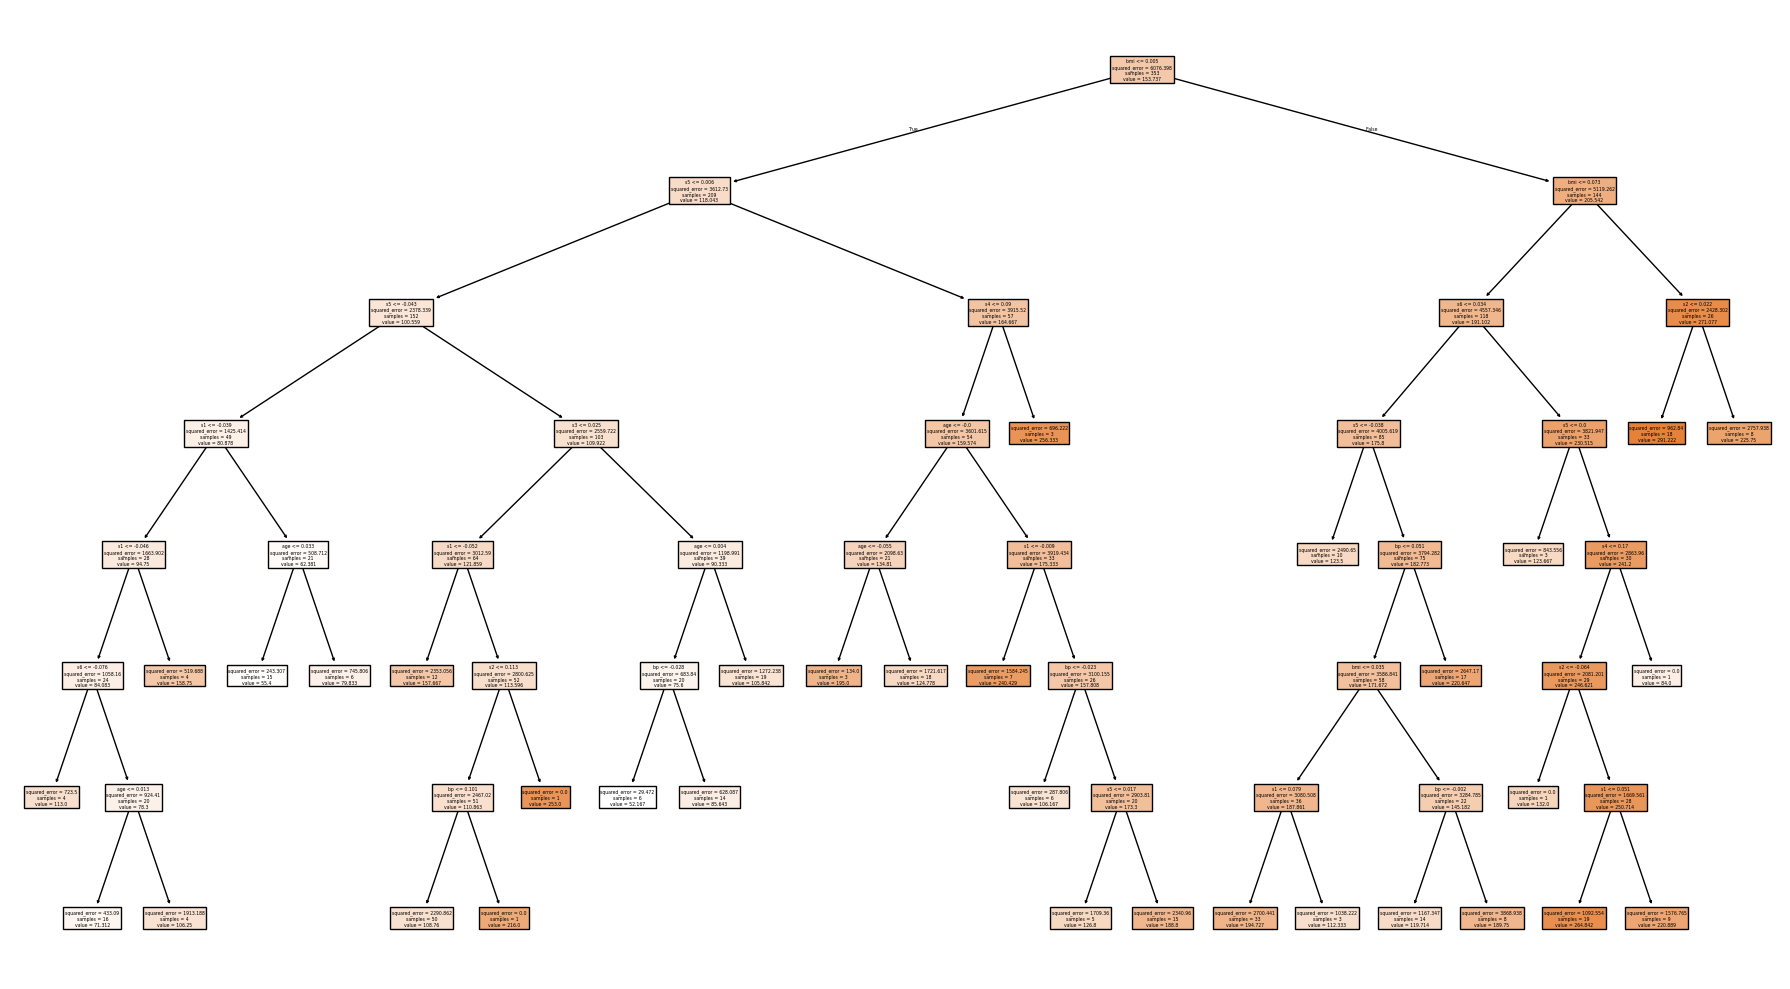

In [18]:
# import plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model, 
    feature_names=x.columns,
    filled=True
)

plt.tight_layout()
plt.show()